# Model 1: Logistic Regression

Baseline interpretable model predicting concentration-driven portfolio risk from HHI, top-holding percentage, number of holdings, sector HHI, and total portfolio value.

In [10]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import joblib
import os

## Configuration and Data Load

In [11]:
PROCESSED_DATA_DIR = "../../data/processed"
ARTIFACTS_DIR = "../../artifacts"
REPORTS_DIR = "../../reports"

model_data = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "model_features.csv"))

## Time-Based Train/Test Split

A random split would risk leakage across quarters given the panel structure of this data. Training uses earlier quarters; the two most recent quarters are held out for testing.

In [12]:
quarter_order = ["2015-03", "2015-06", "2015-09", "2015-12",
                  "2016-03", "2016-06", "2016-09", "2016-12",
                  "2017-03", "2017-06"]

train_quarters = quarter_order[:-2]
test_quarters = quarter_order[-2:]

train_df = model_data[model_data["quarter"].isin(train_quarters)].copy()
test_df = model_data[model_data["quarter"].isin(test_quarters)].copy()

print(f"Train: {len(train_df)} rows, {train_df['label'].mean():.1%} positive")
print(f"Test: {len(test_df)} rows, {test_df['label'].mean():.1%} positive")

Train: 15151 rows, 5.1% positive
Test: 5093 rows, 1.5% positive


The test set's positive rate (1.5%) is thinner than training (5.1%), a known trade-off of time-based splitting on an already-imbalanced label. Metrics on the positive class should be read with this in mind.

## Fit Model

Features are standardised, since Logistic Regression is scale-sensitive. `class_weight="balanced"` compensates for label imbalance without manual resampling.

In [13]:
feature_cols = ["hhi", "top_holding_pct", "num_holdings", "sector_hhi", "total_value"]

X_train, y_train = train_df[feature_cols], train_df["label"]
X_test, y_test = test_df[feature_cols], test_df["label"]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model1 = LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000)
model1.fit(X_train_scaled, y_train)

print("Model fitted.")

Model fitted.


## Interpret Feature Coefficients

hhi               -0.976832
num_holdings      -0.134125
sector_hhi         0.311316
total_value        0.612243
top_holding_pct    1.917807
dtype: float64


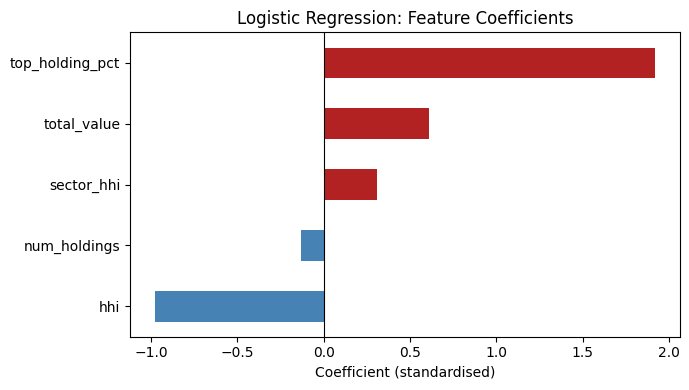

In [14]:
coefs = pd.Series(model1.coef_[0], index=feature_cols).sort_values()
print(coefs)

fig, ax = plt.subplots(figsize=(7, 4))
coefs.plot(kind="barh", ax=ax, color=["firebrick" if c > 0 else "steelblue" for c in coefs])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient (standardised)")
ax.set_title("Logistic Regression: Feature Coefficients")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "charts", "model1_coefficients.png"), dpi=100)
plt.show()

`top_holding_pct` and `sector_hhi` are positive, as expected: higher concentration predicts higher risk. `hhi` is unexpectedly negative, traced to a 0.96 correlation with `top_holding_pct`, a multicollinearity artefact, not a genuine reversal of the underlying relationship (confirmed via correlation analysis; see Model1_Logistic_Regression.MD).

## Evaluate on Test Set

              precision    recall  f1-score   support

           0       1.00      0.82      0.90      5016
           1       0.08      0.95      0.14        77

    accuracy                           0.82      5093
   macro avg       0.54      0.89      0.52      5093
weighted avg       0.99      0.82      0.89      5093

ROC-AUC: 0.935


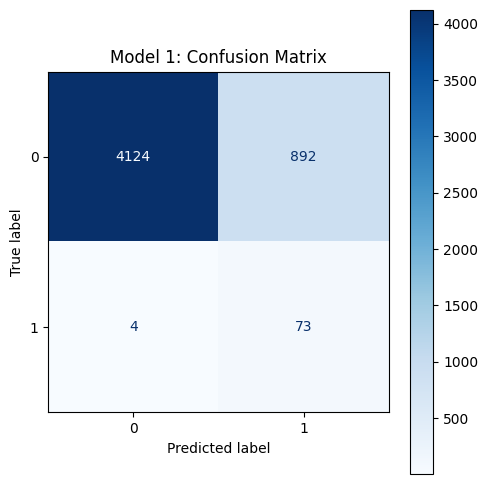

In [15]:
y_pred = model1.predict(X_test_scaled)
y_pred_proba = model1.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.3f}")

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap="Blues")
ax.set_title("Model 1: Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "charts", "model1_confusion_matrix.png"), dpi=100)
plt.show()

ROC-AUC of 0.935 indicates strong ranking ability. Recall on the positive class (0.95) is high while precision is low (0.08), a deliberate consequence of `class_weight="balanced"`, prioritising catching at-risk portfolios over minimising false alarms, a defensible trade-off given the cost of missing genuine risk exceeds the cost of an unnecessary review.

## Save Model

In [17]:
joblib.dump(model1, os.path.join(ARTIFACTS_DIR, "model1_logistic_regression.pkl"))
joblib.dump(scaler, os.path.join(ARTIFACTS_DIR, "model1_scaler.pkl"))
print("Model 1 and scaler saved.")

Model 1 and scaler saved.
